# ISE Competition: Music Genre Multi Classification


## Nạp 4 files vào notebook:

train.csv, test.csv, sample_submission.csv và genre_mapping.


In [2]:
from pathlib import Path

REQUIRED_FILES = (
    "train.csv",
    "test.csv",
    "sample_submission.csv",
    "genre_mapping.csv",
)

try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    colab_files = None
    IN_COLAB = False
if IN_COLAB:
    upload_dir = Path.cwd()
    missing = [
        name for name in REQUIRED_FILES
        if not (upload_dir / name).exists()
    ]
    if missing:
        print("Hãy upload các file còn thiếu:", missing)
        colab_files.upload()

        still_missing = [
            name for name in REQUIRED_FILES
            if not (upload_dir / name).exists()
        ]
        if still_missing:
            raise FileNotFoundError(
                f"Upload chưa đủ hoặc sai tên file: {still_missing}"
            )


Hãy upload các file còn thiếu: ['sample_submission.csv']


Saving genre_mapping.csv to genre_mapping (1).csv
Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


In [3]:
PROJECT_DIR = Path.cwd()
if not all((PROJECT_DIR / name).exists() for name in REQUIRED_FILES):
    PROJECT_DIR = PROJECT_DIR / "ISE_TRAINNING_TEST_23-8-2026"

PROJECT_DIR = PROJECT_DIR.resolve()
missing = [
    name for name in REQUIRED_FILES
    if not (PROJECT_DIR / name).exists()
]
if missing:
    raise FileNotFoundError(f"Thiếu {missing} trong {PROJECT_DIR}")


In [4]:
import numpy as np
import pandas as pd
from IPython.display import display

TARGET = "track_genre"
ID_COLUMN = "track_id"


### Đọc dữ liệu gốc



In [5]:
train = pd.read_csv(PROJECT_DIR / "train.csv")
test = pd.read_csv(PROJECT_DIR / "test.csv")
sample_submission = pd.read_csv(PROJECT_DIR / "sample_submission.csv")
genre_mapping = pd.read_csv(PROJECT_DIR / "genre_mapping.csv")


In [6]:
display(pd.DataFrame({
    "data": ["train", "test"],
    "rows": [len(train), len(test)],
    "columns": [train.shape[1], test.shape[1]],
    "unique_track_id": [train[ID_COLUMN].nunique(), test[ID_COLUMN].nunique()],
}))
display(train[TARGET].value_counts().describe().to_frame("class_count").T)


,data,rows,columns,unique_track_id
0,train,51452,17,51452
1,test,21947,16,21947


,count,mean,std,min,25%,50%,75%,max
class_count,112.0,459.392857,188.575378,51.0,316.75,488.0,619.75,700.0


Đây là bài toán phân loại bị mất cân bằng lớp, lớp nhiều nhất là 700 mẫu, nhưng ít nhất chỉ là 51 mẫu.

### Kiểm tra độ sạch dữ liệu

Check: đúng 15 feature, đúng thứ tự schema, ID không trùng hoặc giao nhau, không có NaN/inf và miền nhãn đúng 0–111


In [7]:
N_CLASSES = genre_mapping["genre_id"].nunique()
EXPECTED_LABELS = np.arange(N_CLASSES)
FEATURES = [column for column in test.columns if column != ID_COLUMN]
y = train[TARGET].to_numpy(dtype=np.int64)

assert N_CLASSES == 112
assert len(FEATURES) == 15
assert list(train.columns) == [ID_COLUMN, *FEATURES, TARGET]
assert list(test.columns) == [ID_COLUMN, *FEATURES]
assert train[ID_COLUMN].is_unique and test[ID_COLUMN].is_unique
assert set(train[ID_COLUMN]).isdisjoint(test[ID_COLUMN])
assert not train[FEATURES].isna().any().any()
assert not test[FEATURES].isna().any().any()
assert np.isfinite(train[FEATURES].to_numpy(dtype=float)).all()
assert np.isfinite(test[FEATURES].to_numpy(dtype=float)).all()
assert np.array_equal(np.unique(y), EXPECTED_LABELS)
assert np.array_equal(
    np.sort(genre_mapping["genre_id"].unique()),
    EXPECTED_LABELS,
)

print("PASS — schema, ID, NaN/inf và 112 labels hợp lệ.")


PASS — schema, ID, NaN/inf và 112 labels hợp lệ.


## Kiểm tra dữ liệu


In [8]:
raw_train = train[FEATURES]
raw_test = test[FEATURES]
group_id = pd.util.hash_pandas_object(raw_train, index=False).astype("uint64")

mixed_label_groups = (
    pd.DataFrame({"group": group_id, "target": y})
    .groupby("group")["target"]
    .nunique()
    .gt(1)
    .sum()
)
assert mixed_label_groups == 0

print("Unique feature rows:", group_id.nunique())
print("Duplicate rows beyond first:", len(train) - group_id.nunique())


Unique feature rows: 50049
Duplicate rows beyond first: 1403


Qua kiểm tra sơ bộ thấy có nhiều dòng trùng nhau, viết code kiểm tra bằng python thì có tới 1403 dòng bị trùng nhau y hệt.

In [9]:
# Kiểm tra xem có group nào chứa nhiều hơn 1 nhãn khác nhau không (tức là giống y hệt nhau)
# 15 features nhưng nhãn genre lại khác nhau.
group_check = pd.DataFrame({'group': group_id, 'target': y})
label_counts_per_group = group_check.groupby('group')['target'].nunique()

mixed_labels = label_counts_per_group[label_counts_per_group > 1]

if len(mixed_labels) == 0:
    print("Kết quả: KHÔNG CÓ. Tất cả các dòng có feature giống hệt nhau đều có cùng một nhãn.")
    print(f"Tổng số nhóm trùng lặp: {len(label_counts_per_group[label_counts_per_group > 1])}")
else:
    print(f"CẢNH BÁO: Có {len(mixed_labels)} nhóm feature bị đánh nhãn khác nhau!")
    display(mixed_labels.head())

Kết quả: KHÔNG CÓ. Tất cả các dòng có feature giống hệt nhau đều có cùng một nhãn.
Tổng số nhóm trùng lặp: 0


### Chiến thuật: Gom các track có trùng hết 15 đặc trưng với nhau lại thành các group, mỗi group chỉ được xuất hiện cùng nhau toàn bộ ở tập train hoặc tập validation.

Nếu không thì: Model nhìn thấy bản ghi 15 feature này ở train, xong ở validation model lại nhìn thấy một bản ghi 15 feature y hệt => Nó từng nhìn thấy 1 trường hợp y hệt ở train rồi nên nó dễ dàng đoán được chính xác ở validation => Data leakage, đánh giá ko còn khách quan chính xác. Tập test/ validation vốn nên chứa những bản ghi mà model chưa thấy bao giờ.

Vì sao không xóa các dòng bị duplicated đi, chỉ để lại 1 dòng duy nhất? Vì như thế làm mất thông tin về độ phổ biến của 15 đặc trưng đó, để nguyên 1 group trong tập train/ validation sẽ giúp model đánh giá được mức độ phổ biến của nhóm đặc trưng giống y hệt nhau đó.

### Chiến thuật Cross-validation: Tạo 3 phiên bản khác nhau của cùng 1 model bất kì, với 3 tập validation khác nhau.

StratifiedGroupKFold: stratified để 112 genre được phân bố cân đối vào cả 3 tập validation, group để mọi bản sao y hệt nhau ở cùng một tập validation.


In [10]:
from sklearn.model_selection import StratifiedGroupKFold

SEED = 20_260_823
N_SPLITS = 3
splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)
splits = list(splitter.split(raw_train, y, groups=group_id))


### Kiểm tra các tập vừa tạo

Ở trên ta đã tách được ra 3 tập validation gọi là A, B, C

Ở mỗi Cross validation rounds, ta sẽ validate model bằng 1 tập và train model bằng 2 tập còn lại.

Cell này kiểm tra mỗi dòng được gán đúng một tập validation, mỗi tập có đủ 112 lớp và không có group nào xuất hiện ở cả 2 tập.


In [32]:
fold_assignment = np.full(len(train), -1, dtype=np.int8)
fold_audit = []

# Gán nhãn cho các tập dựa trên số dòng thực tế
# Vòng 1: Validation = 17157 (A)
# Vòng 2: Validation = 17179 (B)
# Vòng 3: Validation = 17116 (C)
labels = ['A', 'B', 'C']

for fold, (train_idx, valid_idx) in enumerate(splits):
    fold_assignment[valid_idx] = fold
    val_label = labels[fold]
    train_labels = "+".join([labels[i] for i in range(3) if i != fold])

    fold_audit.append({
        "Vòng Cross-validation": f"Vòng {fold + 1}",
        "Tập Validation": f"{len(valid_idx)} ({val_label})",
        "Tập Train": f"{len(train_idx)} ({train_labels})",
        "Số lớp trong Validation": np.unique(y[valid_idx]).size,
        "Số Group trùng lặp (Leakage)": len(set(group_id.iloc[train_idx]) & set(group_id.iloc[valid_idx])),
    })

assert np.all(fold_assignment >= 0)
display(pd.DataFrame(fold_audit))
print("KẾT QUẢ: Đạt yêu cầu - Kí hiệu A, B, C đã được khớp với số dòng tương ứng.")

,Vòng Cross-validation,Tập Validation,Tập Train,Số lớp trong Validation,Số Group trùng lặp (Leakage)
0,Vòng 1,17157 (A),34295 (B+C),112,0
1,Vòng 2,17179 (B),34273 (A+C),112,0
2,Vòng 3,17116 (C),34336 (A+B),112,0


KẾT QUẢ: Đạt yêu cầu - Kí hiệu A, B, C đã được khớp với số dòng tương ứng.


## Kế hoạch và model sử dụng

Sử dụng bộ 3 model cây: XGBoost, Extra Trees và LightGBM. Mục tiêu là huấn luyện chúng trên dữ liệu thô (15 features gốc) và đánh giá nhanh trên Fold 0 để lấy mốc Macro F1.

Sử dụng model họ nhà cây bởi vì dữ liệu dự đoán của chúng ta là dạng bảng, nhiều nhãn, phù hợp với các model cây.

In [34]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import f1_score
import time

# 1. Chuẩn bị dữ liệu từ Fold 0
train_idx, valid_idx = splits[0]
X_train_raw = raw_train.iloc[train_idx]
y_train = y[train_idx]
X_valid_raw = raw_train.iloc[valid_idx]
y_valid = y[valid_idx]

# 2. Định nghĩa các model Baseline
models = {
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        tree_method='hist', random_state=SEED, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=120, min_samples_leaf=2,
        n_jobs=-1, random_state=SEED
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, learning_rate=0.1,
        random_state=SEED, n_jobs=-1, verbosity=-1
    )
}

# 3. Huấn luyện và Đánh giá
baseline_results = []

for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train_raw, y_train)
    duration = time.perf_counter() - start

    preds = model.predict(X_valid_raw)
    score = f1_score(y_valid, preds, average='macro')

    baseline_results.append({
        "Model": name,
        "Macro F1 (Fold 0)": score,
        "Training Time (s)": round(duration, 2)
    })

# 4. Hiển thị kết quả
df_baseline = pd.DataFrame(baseline_results).sort_values("Macro F1 (Fold 0)", ascending=False)
display(df_baseline)

print("\nNhận xét:")
# Sửa lỗi typo ở tên cột
print(f"- Model mạnh nhất hiện tại là {df_baseline.iloc[0]['Model']} với F1 = {df_baseline.iloc[0]['Macro F1 (Fold 0)']:.5f}.")
print("- Đây là kết quả trên data raw, chúng ta sẽ cải thiện con số này bằng Feature Engineering ở chặng tiếp theo.")

,Model,Macro F1 (Fold 0),Training Time (s)
0,XGBoost,0.377189,138.63
1,Extra Trees,0.331100,7.70
2,LightGBM,0.057930,59.73



Nhận xét:
- Model mạnh nhất hiện tại là XGBoost với F1 = 0.37719.
- Đây là kết quả trên data raw, chúng ta sẽ cải thiện con số này bằng Feature Engineering ở chặng tiếp theo.


Chiến thuật sử dụng: Enssemble: Kết hợp 3 model cây lại với nhau để tạo ra xác suất 1 dữ liệu thuộc genre nào.

Ưu điểm của XGBoost: Mạnh, nhìn ra được các quan hệ phi tuyến phức tạp.

Ưu điểm của Extra Trees: Tạo nhiều cây với mức ngẫu nhiên cao hơn Random Forest, vì vậy giảm phương sai và ít bám vào một vài pattern cụ thể. Dù điểm đơn lẻ không cao nhất, model này có diversity tốt, giúp ensemble sửa một phần lỗi mà boosting models cùng mắc phải.

LightGBM: Nổi bật ở khả năng xử lý trực tiếp các biến categorical (explicit, key, mode, time_signature). Train nhanh, tiết kiệm bộ nhớ và tạo góc nhìn dự đoán khác XGBoost, nên hữu ích khi ensemble.

# Feature enginnering cho 3 model

Kết quả ở trên thực sự rất tệ đặc biệt là LightBGM vì nó hiểu lầm dữ liệu của chúng ta, ta cần feature engineering dữ liệu.

# Tạo feature mới và chuẩn hóa cho XGBoost

key=11 không thật sự lớn hơn key=1, nên mã hóa key và time signature theo one-hot, thêm biểu diễn vòng tròn/circle of fifths và một số interaction có ý nghĩa âm nhạc


In [12]:
def engineered_features(frame):
    result = frame[FEATURES].copy()
    key = result.pop("key").astype(int)
    time_signature = result.pop("time_signature").astype(int)

    for value in range(12):
        result[f"key_{value}"] = (key == value).astype(np.int8)
    for value in range(6):
        result[f"time_signature_{value}"] = (
            time_signature == value
        ).astype(np.int8)

    angle = 2 * np.pi * key / 12
    result["key_sin"] = np.sin(angle)
    result["key_cos"] = np.cos(angle)
    fifth_angle = 2 * np.pi * ((key * 7) % 12) / 12
    result["circle_of_fifths_sin"] = np.sin(fifth_angle)
    result["circle_of_fifths_cos"] = np.cos(fifth_angle)

    key_mode = key + 12 * result["mode"].astype(int)
    for value in range(24):
        result[f"key_mode_{value}"] = (key_mode == value).astype(np.int8)

    result["acoustic_low_energy"] = result["acousticness"] * (1 - result["energy"])
    result["energy_loudness"] = result["energy"] * (result["loudness"] + 60)
    result["dance_energy"] = result["danceability"] * result["energy"]
    result["dance_valence"] = result["danceability"] * result["valence"]
    result["speech_explicit"] = result["speechiness"] * (
        1 + result["explicit"].astype(float)
    )
    result["instrumental_acoustic"] = (
        result["instrumentalness"] * result["acousticness"]
    )
    result["tempo_dance"] = result["tempo"] * result["danceability"]
    result["audio_missing"] = (
        result[["danceability", "speechiness", "valence", "tempo"]]
        .eq(0)
        .all(axis=1)
        .astype(np.int8)
    )
    return result.astype(np.float32)


xgb_train = engineered_features(train)
xgb_test = engineered_features(test)
assert list(xgb_train.columns) == list(xgb_test.columns)

print("XGBoost feature shape:", xgb_train.shape)


XGBoost feature shape: (51452, 67)


### 1. One-hot cho key và time_signature

```python
for value in range(12):
    result[f"key_{value}"] = (key == value).astype(np.int8)

```

`key` là biến phân loại gồm 12 tông nhạc, không phải số liên tục. Không thể hiểu `key=11` “lớn hơn” hay “xa hơn” `key=1` theo ý nghĩa âm nhạc. Do đó notebook tạo 12 cột `key_0` đến `key_11`; mỗi bài nhạc chỉ có một cột bằng 1.

Tương tự:

```python
for value in range(6):
    result[f"time_signature_{value}"] = ...

```

Tạo 6 cột cho các giá trị nhịp. Điều này giúp XGBoost học rule kiểu: *“nếu nhịp là 4/4 và energy cao thì nghiêng về genre nào đó”*.

---

### 2. Mã hóa tính tuần hoàn của tông nhạc

```python
angle = 2 * np.pi * key / 12
result["key_sin"] = np.sin(angle)
result["key_cos"] = np.cos(angle)

```

12 tông nhạc nằm trên một vòng tròn: `key=11` gần `key=0`, chứ không xa như trên trục số thông thường. Hai cột sin/cos biểu diễn tông nhạc theo tọa độ vòng tròn, giữ được quan hệ “quay vòng” này.

Notebook giữ cả one-hot lẫn sin/cos vì chúng bổ sung nhau:

* **One-hot:** Tốt để học các rule riêng cho từng tông.
* **sin/cos:** Giúp model thấy các tông gần nhau về mặt tuần hoàn.

---

### 3. Circle of fifths

```python
fifth_angle = 2 * np.pi * ((key * 7) % 12) / 12
result["circle_of_fifths_sin"] = np.sin(fifth_angle)
result["circle_of_fifths_cos"] = np.cos(fifth_angle)

```

Đây là cách biểu diễn theo vòng quãng năm trong âm nhạc. Phép `key * 7 mod 12` sắp lại 12 tông theo quan hệ hòa âm gần gũi hơn; ví dụ các tông cách nhau một quãng năm nằm gần nhau trên vòng này.

Hai feature này cho model thêm một góc nhìn về cấu trúc hòa âm, thay vì chỉ biết mã số key ban đầu.

---

### 4. Kết hợp key và mode

```python
key_mode = key + 12 * result["mode"].astype(int)
for value in range(24):
    result[f"key_mode_{value}"] = (key_mode == value).astype(np.int8)

```

Cùng một key nhưng ở điệu trưởng và thứ có màu sắc cảm xúc khác nhau. Vì vậy notebook tạo 24 nhóm:

* 12 nhóm key ở `mode=0` (thứ)
* 12 nhóm key ở `mode=1` (trưởng)

Ví dụ, model có thể học rằng một nhóm genre thường xuất hiện ở vài tổ hợp “tông + trưởng/thứ” nhất định.

---

### 5. Các interaction feature âm học

| Feature mới | Công thức | Ý nghĩa |
| --- | --- | --- |
| `acoustic_low_energy` | `acousticness × (1 - energy)` | Cao khi bài nhạc vừa acoustic vừa ít năng lượng; hữu ích để nhận diện các phong cách nhẹ/chậm. |
| `energy_loudness` | `energy × (loudness + 60)` | Kết hợp cường độ cảm nhận với độ lớn. `+60` dịch loudness vốn thường âm sang vùng dương hơn. |
| `dance_energy` | `danceability × energy` | Cao khi bài vừa dễ nhảy vừa mạnh; có thể hữu ích cho dance, EDM, pop năng lượng cao. |
| `dance_valence` | `danceability × valence` | Kết hợp độ dễ nhảy và sắc thái vui vẻ/tích cực. |
| `speech_explicit` | `speechiness × (1 + explicit)` | Tăng trọng số speechiness nếu bài có nhãn explicit; có thể giúp phân biệt các bài nhiều lời nói/rap. |
| `instrumental_acoustic` | `instrumentalness × acousticness` | Cao khi vừa thiên về không lời vừa acoustic. |
| `tempo_dance` | `tempo × danceability` | Phân biệt bài nhanh nhưng không dễ nhảy với bài nhanh và có nhịp nhảy rõ. |
| `audio_missing` | Bốn cột đều bằng 0 | Cờ đánh dấu bản ghi có thể thiếu/không đáng tin dữ liệu âm học. |

**Điểm quan trọng:** XGBoost có thể tự học tương tác qua các split của cây, nhưng việc tạo sẵn các tích như `dance_energy` hay `instrumental_acoustic` giúp model tiếp cận trực tiếp các pattern có ý nghĩa miền âm nhạc, nhất là khi dữ liệu không quá lớn.


### Đánh dấu categorical feature cho LightGBM

LightGBM có thể xử lý trực tiếp bốn biến rời rạc. Cell này chỉ tạo hai bảng dành cho LightGBM và ép train/test dùng cùng domain category; Extra Trees vẫn dùng nguyên 15 feature thô.


In [13]:
CATEGORICAL = ["explicit", "key", "mode", "time_signature"]
CATEGORY_DOMAINS = {
    "explicit": [False, True],
    "key": list(range(12)),
    "mode": [0, 1],
    "time_signature": list(range(6)),
}

lgb_train = raw_train.copy()
lgb_test = raw_test.copy()
for column in CATEGORICAL:
    fixed_dtype = pd.CategoricalDtype(categories=CATEGORY_DOMAINS[column])
    lgb_train[column] = lgb_train[column].astype(fixed_dtype)
    lgb_test[column] = lgb_test[column].astype(fixed_dtype)

assert list(lgb_train.columns) == list(lgb_test.columns)
print("LightGBM feature shape:", lgb_train.shape)


LightGBM feature shape: (51452, 15)


#Huấn luyện ba mô hình bằng Cross-validation

### Chuẩn bị model và cách ghi điểm macro f1



In [35]:
if IN_COLAB:
    import subprocess
    import sys

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "xgboost>=3.4,<4", "lightgbm>=4.7,<5",
    ])

import gc
import os
import time
import warnings

import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss, recall_score
from xgboost import XGBClassifier

MODEL_SEED = 42
N_JOBS = max(1, min(8, os.cpu_count() or 2))


def macro_f1(y_true, y_pred):
    return float(f1_score(
        y_true,
        y_pred,
        labels=EXPECTED_LABELS,
        average="macro",
        zero_division=0,
    ))


def save_metrics(rows, name, fold, valid_idx, probability, elapsed):
    prediction = probability.argmax(axis=1)
    row = {
        "model": name,
        "fold": fold,
        "macro_f1": macro_f1(y[valid_idx], prediction),
        "accuracy": accuracy_score(y[valid_idx], prediction),
        "log_loss": log_loss(
            y[valid_idx],
            probability,
            labels=EXPECTED_LABELS,
        ),
        "seconds": elapsed,
    }
    rows.append(row)
    print(
        f"fold={fold + 1} F1={row['macro_f1']:.6f} "
        f"acc={row['accuracy']:.6f} time={elapsed:.1f}s",
        flush=True,
    )


Train cùng 1 loại mô hình 3 lần với 3 tập train và validate thay đổi luân phiên tạo ra 3 mô hình trong cùng 1 họ. Kết quả cuối cùng của 1 họ mô hình sẽ lấy trung bình cộng của 3 mô hình trong đó.


In [15]:
MODEL_NAMES = ("extra_trees", "lightgbm", "xgboost")
oof_probability = {
    name: np.zeros((len(train), N_CLASSES), dtype=np.float32)
    for name in MODEL_NAMES
}
test_probability = {
    name: np.zeros((len(test), N_CLASSES), dtype=np.float64)
    for name in MODEL_NAMES
}
metric_rows = []
best_iterations = {"lightgbm": [], "xgboost": []}


### Model 1 — Extra Trees trên feature thô

Extra Trees yếu hơn boosting nhưng tạo một góc nhìn khác nhờ nhiều cây ngẫu nhiên. Cell này chỉ chạy Extra Trees qua ba fold, điền xác suất OOF/test và ghi metric của model này.


In [16]:
raw_train_float = raw_train.astype(np.float32)
raw_test_float = raw_test.astype(np.float32)

for fold, (train_idx, valid_idx) in enumerate(splits):
    started = time.perf_counter()
    model = ExtraTreesClassifier(
        n_estimators=120,
        max_features=1.0,
        min_samples_leaf=2,
        n_jobs=N_JOBS,
        random_state=MODEL_SEED + fold,
    )
    model.fit(raw_train_float.iloc[train_idx], y[train_idx])
    valid_probability = model.predict_proba(raw_train_float.iloc[valid_idx])

    oof_probability["extra_trees"][valid_idx] = valid_probability.astype(np.float32)
    test_probability["extra_trees"] += (
        model.predict_proba(raw_test_float) / N_SPLITS
    )
    save_metrics(
        metric_rows,
        "extra_trees",
        fold,
        valid_idx,
        valid_probability,
        time.perf_counter() - started,
    )
    del model, valid_probability
    gc.collect()


fold=1 F1=0.352814 acc=0.419654 time=36.2s
fold=2 F1=0.362676 acc=0.426451 time=20.4s
fold=3 F1=0.362301 acc=0.426969 time=22.0s


### Model 2 — LightGBM với categorical feature

LightGBM nhận bốn cột categorical đã chuẩn bị ở trên và dùng early stopping trên validation fold. Cell này chỉ tạo xác suất OOF/test của LightGBM và lưu số vòng tốt nhất ở từng fold.


In [17]:
for fold, (train_idx, valid_idx) in enumerate(splits):
    started = time.perf_counter()
    model = LGBMClassifier(
        objective="multiclass",
        num_class=N_CLASSES,
        n_estimators=1_200,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        max_bin=255,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.9,
        reg_lambda=3.0,
        reg_alpha=0.05,
        n_jobs=N_JOBS,
        random_state=MODEL_SEED + fold,
        verbosity=-1,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model.fit(
            lgb_train.iloc[train_idx],
            y[train_idx],
            eval_set=[(lgb_train.iloc[valid_idx], y[valid_idx])],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(60, verbose=False)],
            categorical_feature=CATEGORICAL,
        )
    valid_probability = model.predict_proba(lgb_train.iloc[valid_idx])

    oof_probability["lightgbm"][valid_idx] = valid_probability.astype(np.float32)
    test_probability["lightgbm"] += model.predict_proba(lgb_test) / N_SPLITS
    best_iterations["lightgbm"].append(int(model.best_iteration_))
    save_metrics(
        metric_rows,
        "lightgbm",
        fold,
        valid_idx,
        valid_probability,
        time.perf_counter() - started,
    )
    del model, valid_probability
    gc.collect()


fold=1 F1=0.385847 acc=0.449263 time=296.2s
fold=2 F1=0.400362 acc=0.457011 time=291.6s
fold=3 F1=0.393844 acc=0.452910 time=265.4s


### Model 3 — XGBoost trên feature đã engineering

XGBoost là model đơn mạnh nhất trong screening. Cell này chỉ huấn luyện nó qua ba fold với early stopping, sau đó điền xác suất OOF/test và số vòng tốt nhất.


In [18]:
for fold, (train_idx, valid_idx) in enumerate(splits):
    started = time.perf_counter()
    model = XGBClassifier(
        n_estimators=700,
        learning_rate=0.06,
        max_depth=7,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.9,
        reg_lambda=5.0,
        reg_alpha=0.05,
        objective="multi:softprob",
        num_class=N_CLASSES,
        eval_metric="mlogloss",
        tree_method="hist",
        max_bin=256,
        n_jobs=N_JOBS,
        random_state=MODEL_SEED + fold,
        early_stopping_rounds=45,
    )
    model.fit(
        xgb_train.iloc[train_idx],
        y[train_idx],
        eval_set=[(xgb_train.iloc[valid_idx], y[valid_idx])],
        verbose=False,
    )
    valid_probability = model.predict_proba(xgb_train.iloc[valid_idx])

    oof_probability["xgboost"][valid_idx] = valid_probability.astype(np.float32)
    test_probability["xgboost"] += model.predict_proba(xgb_test) / N_SPLITS
    best_iterations["xgboost"].append(int(model.best_iteration + 1))
    save_metrics(
        metric_rows,
        "xgboost",
        fold,
        valid_idx,
        valid_probability,
        time.perf_counter() - started,
    )
    del model, valid_probability
    gc.collect()


fold=1 F1=0.391444 acc=0.452352 time=485.7s
fold=2 F1=0.402124 acc=0.460271 time=496.3s
fold=3 F1=0.400006 acc=0.459336 time=506.4s


### So sánh và kiểm tra đầu ra ba model


In [19]:
for probabilities in [*oof_probability.values(), *test_probability.values()]:
    assert np.isfinite(probabilities).all()
    assert np.allclose(probabilities.sum(axis=1), 1, atol=2e-4)

base_metrics = pd.DataFrame(metric_rows)
display(base_metrics)
display(base_metrics.groupby("model")["macro_f1"].agg(["mean", "std"]))
print("Best iterations:", best_iterations)
print(f"Total model runtime: {base_metrics['seconds'].sum():.1f}s")


,model,fold,macro_f1,accuracy,log_loss,seconds
0,extra_trees,0,0.352814,0.419654,3.274145,36.219455
1,extra_trees,1,0.362676,0.426451,3.319813,20.356635
2,extra_trees,2,0.362301,0.426969,3.374904,22.018732
3,lightgbm,0,0.385847,0.449263,2.155299,296.213728
4,lightgbm,1,0.400362,0.457011,2.128078,291.634939
5,lightgbm,2,0.393844,0.452910,2.142852,265.400681
6,xgboost,0,0.391444,0.452352,2.114540,485.744263
7,xgboost,1,0.402124,0.460271,2.093252,496.277179
8,xgboost,2,0.400006,0.459336,2.099969,506.442825


,mean,std
model,,
extra_trees,0.359264,0.005588
lightgbm,0.393351,0.007270
xgboost,0.397858,0.005655


Best iterations: {'lightgbm': [150, 154, 142], 'xgboost': [271, 277, 280]}
Total model runtime: 2420.3s



# Trộn ba model

XGBoost mạnh nhất nên nhận trọng số 0.40; Extra Trees nhận 0.35 vì diversity; LightGBM nhận 0.25. Cell này chỉ lấy trung bình có trọng số của ba model.


In [20]:
WEIGHTS = {
    "xgboost": 0.40,
    "lightgbm": 0.25,
    "extra_trees": 0.35,
}
assert np.isclose(sum(WEIGHTS.values()), 1.0)

oof_blend = sum(
    WEIGHTS[name] * oof_probability[name]
    for name in WEIGHTS
)
test_blend = sum(
    WEIGHTS[name] * test_probability[name]
    for name in WEIGHTS
)


### Điều chỉnh OOF theo class prior của từng training fold

Macro F1 cho mỗi genre tiếng nói ngang nhau dù số mẫu rất lệch. Tôi dùng prior correction nhẹ với alpha 0.35. Để tránh leakage, prior của mỗi validation row chỉ được tính từ phần training của fold tương ứng. Cell này chỉ tạo `oof_adjusted`.


In [21]:
PRIOR_ALPHA = 0.35
oof_adjusted = np.empty_like(oof_blend, dtype=np.float64)

for train_idx, valid_idx in splits:
    fold_count = np.bincount(y[train_idx], minlength=N_CLASSES).astype(float)
    fold_prior = fold_count / fold_count.sum()
    adjusted = oof_blend[valid_idx] / np.power(
        fold_prior[None, :],
        PRIOR_ALPHA,
    )
    oof_adjusted[valid_idx] = adjusted / adjusted.sum(axis=1, keepdims=True)

assert np.isfinite(oof_adjusted).all()
assert np.allclose(oof_adjusted.sum(axis=1), 1)


### Chấm ensemble trước calibration

Cell này chuyển xác suất OOF đã điều chỉnh thành nhãn và báo Macro F1 theo từng fold lẫn toàn bộ OOF. Đây là mốc đối chứng để biết threshold calibration ở chặng sau có thật sự cải thiện hay không.


In [22]:
base_oof_prediction = oof_adjusted.argmax(axis=1)
fold_scores = [
    macro_f1(y[valid_idx], base_oof_prediction[valid_idx])
    for _, valid_idx in splits
]
ensemble_summary = pd.DataFrame({
    "fold": range(N_SPLITS),
    "macro_f1": fold_scores,
})

display(ensemble_summary)
print(f"Fold mean: {np.mean(fold_scores):.6f}")
print(f"Fold std:  {np.std(fold_scores, ddof=1):.6f}")
print(f"Global OOF Macro F1: {macro_f1(y, base_oof_prediction):.6f}")
print(f"Global OOF accuracy: {accuracy_score(y, base_oof_prediction):.6f}")
print(
    "Global OOF macro recall:",
    f"{recall_score(y, base_oof_prediction, labels=EXPECTED_LABELS, average='macro', zero_division=0):.6f}",
)


,fold,macro_f1
0,0,0.400143
1,1,0.412776
2,2,0.407890


Fold mean: 0.406936
Fold std:  0.006370
Global OOF Macro F1: 0.407650
Global OOF accuracy: 0.464997
Global OOF macro recall: 0.412883


#Không để các genre nhỏ biến mất

### Định nghĩa cách học threshold cho từng lớp

Vài genre hiếm vẫn bị lớp đông lấn át. Cell này chỉ định nghĩa hàm tìm threshold tối đa hóa F1 nhị phân trên precision–recall curve cho từng genre; nó chưa chọn gamma và chưa nhìn test.


In [23]:
from sklearn.metrics import precision_recall_curve


def fit_class_thresholds(mask):
    thresholds = np.empty(N_CLASSES, dtype=np.float64)
    for class_id in EXPECTED_LABELS:
        precision, recall, candidates = precision_recall_curve(
            y[mask] == class_id,
            oof_adjusted[mask, class_id],
        )
        binary_f1 = 2 * precision * recall / np.maximum(
            precision + recall,
            1e-15,
        )
        best_index = int(np.nanargmax(binary_f1[:-1]))
        thresholds[class_id] = max(float(candidates[best_index]), 1e-8)
    return thresholds


# Chọn mức ảnh hưởng của threshold bằng cross-fold



In [24]:
gamma_grid = np.round(np.arange(0.0, 1.01, 0.1), 1)
crossfold_scores = {gamma: [] for gamma in gamma_grid}

for held_out_fold in range(N_SPLITS):
    calibration_mask = fold_assignment != held_out_fold
    validation_mask = fold_assignment == held_out_fold
    thresholds = fit_class_thresholds(calibration_mask)

    for gamma in gamma_grid:
        prediction = (
            oof_adjusted[validation_mask]
            / np.power(thresholds[None, :], gamma)
        ).argmax(axis=1)
        crossfold_scores[gamma].append(
            macro_f1(y[validation_mask], prediction)
        )

calibration_report = pd.DataFrame([
    {
        "gamma": gamma,
        "fold_0": scores[0],
        "fold_1": scores[1],
        "fold_2": scores[2],
        "mean": np.mean(scores),
        "std": np.std(scores, ddof=1),
    }
    for gamma, scores in crossfold_scores.items()
])
BEST_GAMMA = float(
    calibration_report.loc[calibration_report["mean"].idxmax(), "gamma"]
)

display(calibration_report)
print(f"Selected gamma: {BEST_GAMMA}")
print(f"Cross-fold calibrated mean: {calibration_report['mean'].max():.6f}")


,gamma,fold_0,fold_1,fold_2,mean,std
0,0.0,0.400143,0.412776,0.407890,0.406936,0.006370
1,0.1,0.400798,0.412624,0.408624,0.407349,0.006015
2,0.2,0.402793,0.415125,0.409093,0.409004,0.006166
3,0.3,0.402447,0.417397,0.410186,0.410010,0.007477
4,0.4,0.403872,0.417447,0.410813,0.410711,0.006788
5,0.5,0.404501,0.417873,0.411367,0.411247,0.006687
6,0.6,0.404894,0.417770,0.412968,0.411877,0.006507
7,0.7,0.405769,0.417312,0.412754,0.411945,0.005814
8,0.8,0.406359,0.417365,0.412268,0.411997,0.005508
9,0.9,0.406677,0.416701,0.411534,0.411637,0.005013


Selected gamma: 0.8
Cross-fold calibrated mean: 0.411997


### Trực quan hóa kết quả Tuning Gamma
Biểu đồ này cho thấy sự thay đổi của Macro F1 trên 3 fold ứng với các giá trị Gamma khác nhau. Bạn sẽ thấy một 'plateau' (vùng bình nguyên) nơi điểm số ổn định nhất.

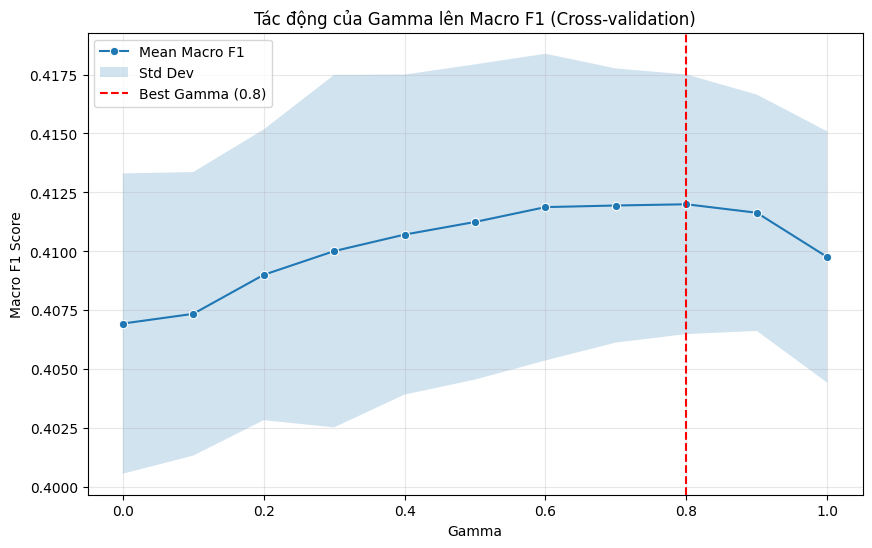

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=calibration_report, x='gamma', y='mean', marker='o', label='Mean Macro F1')
plt.fill_between(calibration_report['gamma'],
                 calibration_report['mean'] - calibration_report['std'],
                 calibration_report['mean'] + calibration_report['std'],
                 alpha=0.2, label='Std Dev')

plt.axvline(BEST_GAMMA, color='red', linestyle='--', label=f'Best Gamma ({BEST_GAMMA})')
plt.title('Tác động của Gamma lên Macro F1 (Cross-validation)')
plt.xlabel('Gamma')
plt.ylabel('Macro F1 Score')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Fit calibration cuối và dự đoán test

In [25]:
final_thresholds = fit_class_thresholds(
    np.ones(len(train), dtype=bool)
)
full_count = np.bincount(y, minlength=N_CLASSES).astype(float)
full_prior = full_count / full_count.sum()
test_adjusted = test_blend / np.power(
    full_prior[None, :],
    PRIOR_ALPHA,
)
test_adjusted /= test_adjusted.sum(axis=1, keepdims=True)
test_prediction = (
    test_adjusted
    / np.power(final_thresholds[None, :], BEST_GAMMA)
).argmax(axis=1)

print("Predicted test classes:", np.unique(test_prediction).size, "/", N_CLASSES)


Predicted test classes: 112 / 112


## Submission

### Dựng và kiểm tra bảng submission trong bộ nhớ



In [26]:
submission = pd.DataFrame({
    ID_COLUMN: test[ID_COLUMN],
    TARGET: test_prediction.astype(np.int64),
})

assert list(submission.columns) == [ID_COLUMN, TARGET]
assert len(submission) == len(test) == len(sample_submission)
assert submission[ID_COLUMN].equals(test[ID_COLUMN])
assert submission[ID_COLUMN].equals(sample_submission[ID_COLUMN])
assert submission[ID_COLUMN].is_unique
assert submission[TARGET].between(0, N_CLASSES - 1).all()
assert set(submission[TARGET]).issubset(set(train[TARGET]))

display(submission.head())
print("PASS — submission đúng schema, thứ tự ID và miền nhãn.")


,track_id,track_genre
0,1XhaUSmhANVIRtDvs7p2UP,21
1,5hN31Cpidm5zklAonL6pKr,34
2,5PqVZR35eth8PUnbHPjZSy,60
3,6bo3wF9Gfmr7iFlIaGfo1g,51
4,2DB21D2l8KmdLXid8327i2,19


PASS — submission đúng schema, thứ tự ID và miền nhãn.


### Ghi file cuối

Chỉ sau khi bảng đã hợp lệ, cell cuối mới ghi CSV và báo lại các thống kê đủ để kiểm tra nhanh. Nếu chạy trên Colab, chính file vừa ghi sẽ được tải xuống.


In [27]:
OUTPUT_PATH = PROJECT_DIR / "submission_final_macro_f1_ensemble.csv"
submission.to_csv(OUTPUT_PATH, index=False)

prediction_counts = submission[TARGET].value_counts().sort_index()
print("Saved:", OUTPUT_PATH)
print("Shape:", submission.shape)
print("Unique IDs:", submission[ID_COLUMN].nunique())
print("Predicted classes:", submission[TARGET].nunique())
print(
    "Prediction count min/median/max:",
    int(prediction_counts.min()),
    float(prediction_counts.median()),
    int(prediction_counts.max()),
)

if IN_COLAB:
    colab_files.download(str(OUTPUT_PATH))


Saved: /content/submission_final_macro_f1_ensemble.csv
Shape: (21947, 2)
Unique IDs: 21947
Predicted classes: 112
Prediction count min/median/max: 3 211.0 471


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>